# IPF NetCoS — Connectivity Scores & Drug Rankings

Data exploration of the **IPF** NetCoS runs (CS + drug-ranking sections of the old
`data_exploration_ipf` notebook, reproduced on the *new, non-bugged* `bin_chen` outputs).

**What changed vs the old notebook**

* The old runs used the buggy 2025 CS (scale ~ ±2). These use the corrected `bin_chen`
  connectivity score (scale ~ ±0.07 for DEG up to ~ ±0.4 for MITHrIL+pathways).
* Output schema is now one row per *(drug, timepoint)* keyed by `pert_id`
  (e.g. `curcumin_24h`), with columns
  `connectivity_score, cs_p_value, pearson, pearson_p_value, spearman, spearman_p_value, cos_sim`.
* The gene-level *DEG-vs-MITHrIL* comparison sections are **out of scope here** (unchanged
  since 2025 — see the project memory note); this notebook covers only CS distributions and rankings.

**Sign convention (important).** A repurposing candidate should *reverse* the IPF signature, i.e.
be **anti-correlated** with it. Empirically the most negative `connectivity_score` rows are the
ones with the most negative `pearson`/`spearman` vs the disease, and the ChEMBL validation
thresholds are negative (−1.5 / −0.1). **So: most-negative CS = strongest reversal = top candidate.**
(The 11/05 log note that `bin_chen` CS = −RGES, implying positive=good, is *not* what the data and
the validation thresholds operationally use — flagged for follow-up.)

## 1. Setup & paths

In [18]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

# Resolve the netcos root relative to this notebook (data_exploration/), with a fallback.
HERE = os.getcwd()
def find_root(start):
    p = start
    for _ in range(6):
        if os.path.isdir(os.path.join(p, 'connectivity_score', 'output')):
            return p
        p = os.path.dirname(p)
    return None

NETCOS_ROOT = find_root(HERE) or find_root(os.path.dirname(HERE)) or \
    r'G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos'
CS_OUT = os.path.join(NETCOS_ROOT, 'connectivity_score', 'output', 'ipf')
IMG_DIR = os.path.join(NETCOS_ROOT, 'imgs', 'ipf_cs_exploration')
os.makedirs(IMG_DIR, exist_ok=True)
print('NETCOS_ROOT :', NETCOS_ROOT)
print('CS_OUT      :', CS_OUT)
assert os.path.isdir(CS_OUT), 'IPF output folder not found'

NETCOS_ROOT : G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos
CS_OUT      : G:\My Drive\Professionale\Ricerca\Assegno di ricerca - Universita di Catania\netcos\connectivity_score\output\ipf


## 2. The five IPF runs

All are `CS_METHOD = bin_chen`, IPF disease signature, all cell lines (`cell_line='all'`),
drug signatures collapsed before CS (LMM/DEG pipeline). They differ in the propagation /
gene-universe knobs:

| label | file | cs_mith | cs_on_LM | pathways |
|---|---|---|---|---|
| `DEG`     | 30_06_2026_10_49_DEG_bin_chen        | 0 | 0 | no |
| `DEG_LM`  | 30_06_2026_13_00_DEG_LM_bin_chen     | 0 | 1 | no |
| `mith`    | 30_06_2026_13_00_mith_bin_chen       | 1 | 0 | no |
| `mith_LM` | 30_06_2026_13_05_mith_LM_bin_chen    | 1 | 1 | no |
| `mith_pw` | 21_06_2026_17_28_mith_pw_bin_chen    | 1 | 0 | yes |

In [19]:
RUN_FILES = {
    'DEG':     '30_06_2026_10_49_DEG_bin_chen_connectivity_score.tsv',
    'DEG_LM':  '30_06_2026_13_00_DEG_LM_bin_chen_connectivity_score.tsv',
    'mith':    '30_06_2026_13_00_mith_bin_chen_connectivity_score.tsv',
    'mith_LM': '30_06_2026_13_05_mith_LM_bin_chen_connectivity_score.tsv',
    'mith_pw': '21_06_2026_17_28_mith_pw_bin_chen_connectivity_score.tsv',
}

TIMEPOINTS = ['6h', '24h', '6h_24h']

def split_pert_id(pid):
    """Split '<drug>_<timepoint>' into (drug, perturbation_time)."""
    for tp in ('6h_24h', '24h', '6h'):
        if pid.endswith('_' + tp):
            return pid[:-(len(tp)+1)], tp
    return pid, np.nan

def load_cs(label):
    fp = os.path.join(CS_OUT, RUN_FILES[label])
    df = pd.read_csv(fp, sep='\t')
    drug_tp = df['pert_id'].apply(split_pert_id)
    df['drug'] = drug_tp.apply(lambda x: x[0])
    df['perturbation_time'] = drug_tp.apply(lambda x: x[1])
    # Normalized join key: DEG files spell punctuated names with commas
    # ('1,2,3,4,5,6-...') while MITHrIL files use dashes ('1-2-3-4-5-6-...').
    # Collapse to alnum-lowercase so the same drug matches across runs.
    df['drug_key'] = df['drug'].str.lower().str.replace(r'[^a-z0-9]', '', regex=True)
    df['config'] = label
    return df

runs = {label: load_cs(label) for label in RUN_FILES}
for label, df in runs.items():
    print(f'{label:8s}  rows={len(df):5d}  drugs={df.drug.nunique():5d}  '
          f'CS[min={df.connectivity_score.min():+.3f}, max={df.connectivity_score.max():+.3f}]')

DEG       rows= 9666  drugs= 3222  CS[min=-0.168, max=+0.127]
DEG_LM    rows= 9666  drugs= 3222  CS[min=-0.223, max=+0.154]
mith      rows= 9669  drugs= 3223  CS[min=-0.234, max=+0.209]
mith_LM   rows= 9669  drugs= 3223  CS[min=-0.227, max=+0.198]
mith_pw   rows= 9669  drugs= 3223  CS[min=-0.506, max=+0.487]


## 3. Ranking helpers

`top_ranking_drugs` returns the strongest reversers (most negative CS) that pass a
significance filter on `cs_p_value` (Monte-Carlo empirical p-value).

In [20]:
def top_ranking_drugs(data, pval=0.05, perturbation_time=None, n_best=20):
    """Most-negative connectivity_score = strongest signature reversal."""
    d = data
    if perturbation_time is not None:
        d = d[d.perturbation_time == perturbation_time]
    d = d[d.cs_p_value <= pval]
    cols = ['drug', 'perturbation_time', 'connectivity_score', 'cs_p_value',
            'pearson', 'spearman', 'cos_sim']
    out = d[cols].sort_values('connectivity_score')
    print(f'{len(out)} drug-signatures with cs_p_value <= {pval}'
          f'{"" if perturbation_time is None else " at "+perturbation_time}')
    return out.head(n_best)

def bottom_ranking_drugs(data, pval=0.05, perturbation_time=None, n_best=20):
    """Most-positive CS = strongest disease *mimics* (anti-candidates)."""
    d = data
    if perturbation_time is not None:
        d = d[d.perturbation_time == perturbation_time]
    d = d[d.cs_p_value <= pval]
    cols = ['drug', 'perturbation_time', 'connectivity_score', 'cs_p_value',
            'pearson', 'spearman', 'cos_sim']
    return d[cols].sort_values('connectivity_score', ascending=False).head(n_best)

## 4. CS distributions across runs

How the propagation knobs reshape the connectivity-score distribution.

In [21]:
def sign_table(runs):
    rows = []
    for label, df in runs.items():
        cs = df.connectivity_score
        sig = df.cs_p_value <= 0.05
        rows.append({
            'config': label,
            'n': len(df),
            'frac_negative': (cs < 0).mean(),
            'frac_sig(p<=.05)': sig.mean(),
            'frac_sig_negative': (sig & (cs < 0)).mean(),
            'cs_min': cs.min(), 'cs_max': cs.max(),
            'cs_p01': cs.quantile(0.01), 'cs_p99': cs.quantile(0.99),
        })
    return pd.DataFrame(rows).set_index('config').round(4)

sign_table(runs)

,n,frac_negative,frac_sig(p<=.05),frac_sig_negative,cs_min,cs_max,cs_p01,cs_p99
config,,,,,,,,
DEG,9666,0.7094,0.7176,0.5483,-0.1685,0.1273,-0.1227,0.0776
DEG_LM,9666,0.6936,0.2053,0.1795,-0.2233,0.1541,-0.1583,0.1088
mith,9669,0.6893,1.0000,0.6893,-0.2340,0.2086,-0.1995,0.1760
mith_LM,9669,0.6654,0.2653,0.2045,-0.2267,0.1979,-0.1737,0.1399
mith_pw,9669,0.4563,0.8847,0.3922,-0.5056,0.4869,-0.3606,0.3931


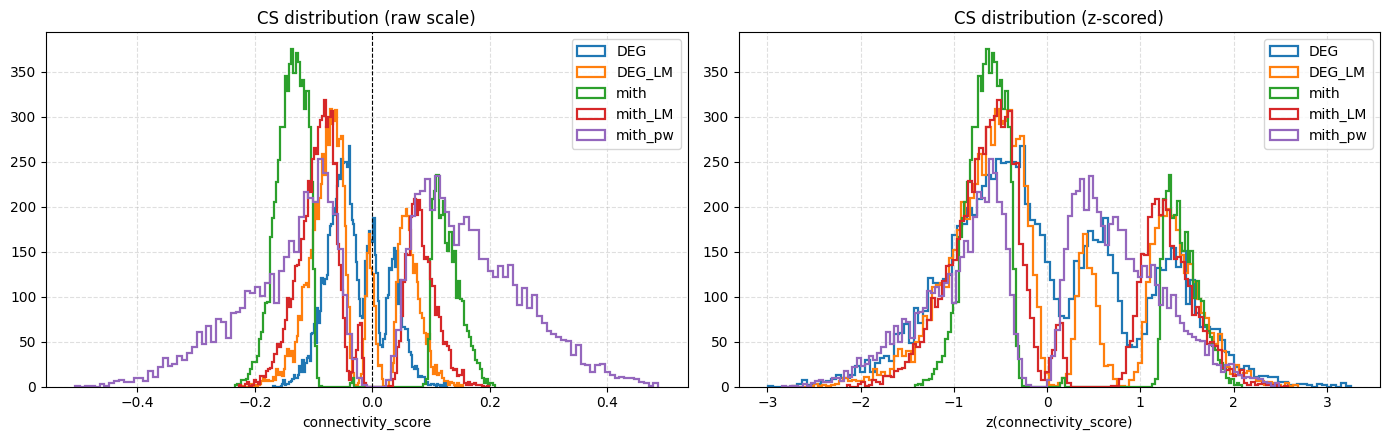

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for label, df in runs.items():
    axes[0].hist(df.connectivity_score, bins=120, histtype='step', lw=1.6, label=label)
axes[0].axvline(0, color='k', lw=0.8, ls='--'); axes[0].set_title('CS distribution (raw scale)')
axes[0].set_xlabel('connectivity_score'); axes[0].legend(); axes[0].grid(ls='--', alpha=.4)
for label, df in runs.items():
    z = (df.connectivity_score - df.connectivity_score.mean()) / df.connectivity_score.std()
    axes[1].hist(z, bins=120, histtype='step', lw=1.6, label=label)
axes[1].set_title('CS distribution (z-scored)'); axes[1].set_xlabel('z(connectivity_score)')
axes[1].legend(); axes[1].grid(ls='--', alpha=.4)
plt.tight_layout(); plt.savefig(os.path.join(IMG_DIR, 'cs_distributions.png'), dpi=120); plt.show()

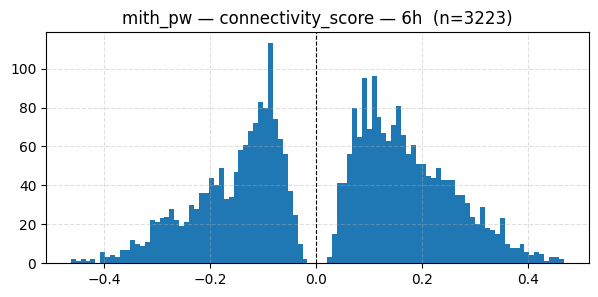

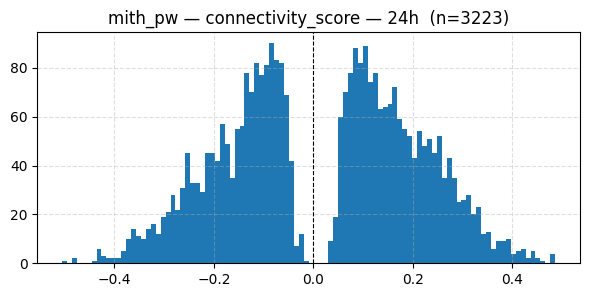

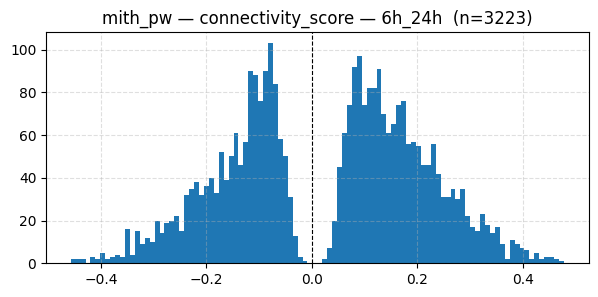

In [23]:
# Per-timepoint distribution for the best-validated config (mith_pw).
def plot_hist_by_timepoint(df, colname='connectivity_score'):
    for tp in TIMEPOINTS:
        sub = df[df.perturbation_time == tp]
        plt.figure(figsize=(7,3))
        plt.hist(sub[colname], bins=100)
        plt.axvline(0, color='k', lw=0.8, ls='--')
        plt.title(f'{df.config.iloc[0]} — {colname} — {tp}  (n={len(sub)})')
        plt.grid(ls='--', alpha=.4); plt.show()

plot_hist_by_timepoint(runs['mith_pw'])

## 5. Sanity check: does negative CS mean reversal?

If most-negative CS are genuine reversers, CS should be *positively* correlated with the
gene-level `pearson`/`spearman` of the drug vs the disease signature (negative CS ↔ negative
correlation = anti-mimics the disease).

In [24]:
for label, df in runs.items():
    r = stats.spearmanr(df.connectivity_score, df.spearman).statistic
    rp = stats.spearmanr(df.connectivity_score, df.pearson).statistic
    print(f'{label:8s}  spearman(CS, gene-spearman)={r:+.3f}   spearman(CS, gene-pearson)={rp:+.3f}')

DEG       spearman(CS, gene-spearman)=+0.960   spearman(CS, gene-pearson)=+0.761
DEG_LM    spearman(CS, gene-spearman)=+0.889   spearman(CS, gene-pearson)=+0.704
mith      spearman(CS, gene-spearman)=+0.967   spearman(CS, gene-pearson)=+0.600
mith_LM   spearman(CS, gene-spearman)=+0.812   spearman(CS, gene-pearson)=+0.559
mith_pw   spearman(CS, gene-spearman)=+0.962   spearman(CS, gene-pearson)=+0.685


## 6. ChEMBL validation guidance (the "training set")

The ChEMBL IC50 validation pipeline acts as a training set for picking hyperparameters.
Top run per cell line (from `logs/top_10_chembl_validation_runs_by_spearman_r.tsv`):

| cell line | disease | best Spearman(CS, IC50) | cs_mith | cs_on_LM | pathways | landmark | → IPF run |
|---|---|---|---|---|---|---|---|
| HEPG2 | LIHC | **0.68** | 1 | 0 | **yes** | yes | `mith_pw` |
| MCF7  | BRCA | **0.59** | 1 | **1** | no | yes | `mith_LM` |
| HT29  | COAD | **0.43** | 0 | **1** | no | yes | `DEG_LM` |

Takeaways the IPF rankings should be read through:

* **MITHrIL propagation (`cs_mith=1`) wins for 2/3 cell lines** (LIHC, BRCA); only COAD
  prefers raw DEG.
* **Landmark filtering appears in every winner.** Prefer `*_LM` / landmark configs.
* **Pathways only helped LIHC.** Treat `mith_pw` as the most aggressive variant.
* No single config dominates; the most defensible IPF candidates are those that rank highly
  in the MITHrIL+landmark runs (`mith_LM`, `mith_pw`).

In [25]:
chembl_best = pd.DataFrame([
    {'cell_line':'HEPG2','disease':'LIHC','spearman_r':0.68,'cs_mith':1,'cs_on_LM':0,'pathways':True ,'ipf_run':'mith_pw'},
    {'cell_line':'MCF7' ,'disease':'BRCA','spearman_r':0.59,'cs_mith':1,'cs_on_LM':1,'pathways':False,'ipf_run':'mith_LM'},
    {'cell_line':'HT29' ,'disease':'COAD','spearman_r':0.43,'cs_mith':0,'cs_on_LM':1,'pathways':False,'ipf_run':'DEG_LM'},
]).set_index('cell_line')
chembl_best

,disease,spearman_r,cs_mith,cs_on_LM,pathways,ipf_run
cell_line,,,,,,
HEPG2,LIHC,0.68,1,0,True,mith_pw
MCF7,BRCA,0.59,1,1,False,mith_LM
HT29,COAD,0.43,0,1,False,DEG_LM


## 7. Top IPF repurposing candidates per run

Most-negative CS, filtered to significant rows (`cs_p_value <= 0.05`). Each drug appears at
3 timepoints; the pooled `6h_24h` is usually the most stable.

In [26]:
print('=== mith_pw ===')
top_ranking_drugs(runs['mith_pw'], pval=0.05, n_best=20)

=== mith_pw ===
8554 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
3723,GW-9662,24h,-0.505596,0.0,-0.627591,-0.650769,-0.745591
9561,vesamicol,24h,-0.482493,0.0,-0.611930,-0.658885,-0.731188
8040,napelline,24h,-0.480719,0.0,-0.696116,-0.683175,-0.792790
9460,tyrphostin-AG-1288,6h,-0.462572,0.0,-0.605802,-0.637473,-0.723757
9025,sotalol,6h,-0.460307,0.0,-0.407129,-0.602070,-0.482198
7358,hydroxychloroquine,6h_24h,-0.457664,0.0,-0.500483,-0.559561,-0.541482
7883,metixene,6h_24h,-0.453450,0.0,-0.425962,-0.634188,-0.475395
1660,BRD-K37940862,6h,-0.446435,0.0,-0.390479,-0.591838,-0.509562
971,BRD-K07101857,6h_24h,-0.445141,0.0,-0.263975,-0.556368,-0.287496
5435,WR-216174,6h_24h,-0.443624,0.0,-0.461836,-0.568583,-0.630295


In [27]:
print('=== mith_LM ===')
top_ranking_drugs(runs['mith_LM'], pval=0.05, n_best=20)

=== mith_LM ===
2565 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
3248,CG-930,6h_24h,-0.226749,0.0,-0.019289,-0.086487,-0.007896
3246,CG-930,24h,-0.226413,0.0,-0.043503,-0.098700,-0.042319
635,BRD-A57107094,6h_24h,-0.214255,0.0,-0.083770,-0.151518,-0.107815
3818,ICI-199441,6h_24h,-0.213960,0.0,-0.101636,-0.186997,-0.133042
992,BRD-K07877311,6h_24h,-0.212960,0.0,-0.132922,-0.182109,-0.207974
3760,HG-5-88-01,6h,-0.211870,0.0,-0.044889,-0.119582,-0.065036
3593,GDC-0879,6h_24h,-0.211812,0.0,-0.080904,-0.144771,-0.143746
9380,tribenoside,6h_24h,-0.211443,0.0,-0.097580,-0.171780,-0.191824
3157,BRL-15572,6h,-0.210648,0.0,-0.065787,-0.156880,-0.143731
9556,verrucarin-a,6h,-0.210148,0.0,-0.166560,-0.209147,-0.181204


In [28]:
print('=== mith ===')
top_ranking_drugs(runs['mith'], pval=0.05, n_best=20)

=== mith ===
9669 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
5157,ST-4029573,24h,-0.233973,0.0,-0.049170,-0.171632,-0.068279
5159,ST-4029573,6h_24h,-0.231639,0.0,-0.061206,-0.181032,-0.078680
6612,digoxin,24h,-0.229843,0.0,-0.086661,-0.166444,-0.101879
6045,bufalin,24h,-0.227929,0.0,-0.095250,-0.180169,-0.109353
8631,proscillaridin,24h,-0.227099,0.0,-0.094407,-0.174321,-0.109201
7313,homoharringtonine,6h_24h,-0.225799,0.0,-0.081408,-0.179576,-0.086442
3855,JAK3-inhibitor-VI,24h,-0.224002,0.0,-0.037525,-0.169522,-0.052231
9048,strophanthidin,24h,-0.222877,0.0,-0.095787,-0.179253,-0.113587
5856,avicin-g,24h,-0.222505,0.0,-0.055883,-0.170810,-0.072834
6420,cymarin,24h,-0.222178,0.0,-0.111936,-0.172641,-0.129429


In [29]:
print('=== DEG_LM ===')
top_ranking_drugs(runs['DEG_LM'], pval=0.05, n_best=20)

=== DEG_LM ===
1984 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
4220,MK-2206,6h,-0.223260,0.0,-0.165644,-0.202939,-0.182492
9553,verrucarin-a,6h_24h,-0.208492,0.0,-0.215576,-0.219414,-0.226341
7310,homoharringtonine,6h,-0.206079,0.0,-0.231051,-0.229184,-0.237081
7309,homoharringtonine,6h_24h,-0.205961,0.0,-0.218211,-0.213474,-0.228644
5456,WZ-4-145,6h,-0.204658,0.0,-0.115557,-0.183037,-0.135162
6784,emetine,6h_24h,-0.201995,0.0,-0.188940,-0.193995,-0.195196
9376,tribenoside,6h_24h,-0.201158,0.0,-0.109905,-0.163842,-0.159157
9554,verrucarin-a,6h,-0.199911,0.0,-0.218803,-0.218448,-0.227625
3992,KU-0063794,6h,-0.197894,0.0,-0.154652,-0.204020,-0.185943
4590,PIK-90,24h,-0.193894,0.0,-0.182042,-0.206444,-0.209582


In [30]:
print('=== DEG ===')
top_ranking_drugs(runs['DEG'], pval=0.05, n_best=20)

=== DEG ===
6936 drug-signatures with cs_p_value <= 0.05


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
7310,homoharringtonine,6h,-0.168479,0.0,-0.150052,-0.193364,-0.149463
7309,homoharringtonine,6h_24h,-0.155981,0.0,-0.135866,-0.178265,-0.136132
6785,emetine,6h,-0.153335,0.0,-0.138347,-0.182891,-0.133810
6190,cephaeline,6h_24h,-0.152790,0.0,-0.139060,-0.183761,-0.137138
4696,QL-X-138,6h_24h,-0.152569,0.0,-0.103168,-0.166144,-0.105019
3907,JW-7-24-1,6h_24h,-0.150453,0.0,-0.109211,-0.162521,-0.115510
5456,WZ-4-145,6h,-0.149737,0.0,-0.108891,-0.166482,-0.112998
3908,JW-7-24-1,6h,-0.149686,0.0,-0.090618,-0.154956,-0.095065
9553,verrucarin-a,6h_24h,-0.149573,0.0,-0.145682,-0.178499,-0.145292
9554,verrucarin-a,6h,-0.149031,0.0,-0.144996,-0.177853,-0.144051


### 7b. Pooled (6h_24h) candidates for the validation-favoured MITHrIL runs

In [14]:
for lbl in ['mith_pw', 'mith_LM']:
    print(f'=== {lbl} — 6h_24h ===')
    display(top_ranking_drugs(runs[lbl], pval=0.05, perturbation_time='6h_24h', n_best=15))

=== mith_pw — 6h_24h ===
2853 drug-signatures with cs_p_value <= 0.05 at 6h_24h


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
7358,hydroxychloroquine,6h_24h,-0.457664,0.0,-0.500483,-0.559561,-0.541482
7883,metixene,6h_24h,-0.453450,0.0,-0.425962,-0.634188,-0.475395
971,BRD-K07101857,6h_24h,-0.445141,0.0,-0.263975,-0.556368,-0.287496
5435,WR-216174,6h_24h,-0.443624,0.0,-0.461836,-0.568583,-0.630295
398,BNTX,6h_24h,-0.438873,0.0,-0.669201,-0.613283,-0.698650
3725,GW-9662,6h_24h,-0.436014,0.0,-0.527479,-0.570405,-0.571224
2000,BRD-K53816294,6h_24h,-0.419877,0.0,-0.523549,-0.550359,-0.601481
626,BRD-A55565369,6h_24h,-0.412368,0.0,-0.367075,-0.565373,-0.350851
2972,BRD-K92863101,6h_24h,-0.411558,0.0,-0.215740,-0.495958,-0.384917
9461,tyrphostin-AG-1288,6h_24h,-0.410803,0.0,-0.527764,-0.555955,-0.674915


=== mith_LM — 6h_24h ===
897 drug-signatures with cs_p_value <= 0.05 at 6h_24h


,drug,perturbation_time,connectivity_score,cs_p_value,pearson,spearman,cos_sim
3248,CG-930,6h_24h,-0.226749,0.0,-0.019289,-0.086487,-0.007896
635,BRD-A57107094,6h_24h,-0.214255,0.0,-0.083770,-0.151518,-0.107815
3818,ICI-199441,6h_24h,-0.213960,0.0,-0.101636,-0.186997,-0.133042
992,BRD-K07877311,6h_24h,-0.212960,0.0,-0.132922,-0.182109,-0.207974
3593,GDC-0879,6h_24h,-0.211812,0.0,-0.080904,-0.144771,-0.143746
9380,tribenoside,6h_24h,-0.211443,0.0,-0.097580,-0.171780,-0.191824
9557,verrucarin-a,6h_24h,-0.204246,0.0,-0.173303,-0.206743,-0.189895
5459,WZ-4-145,6h_24h,-0.201007,0.0,-0.061192,-0.162875,-0.119174
4064,L-694247,6h_24h,-0.200802,0.0,-0.085084,-0.135397,-0.123529
4238,MLN-8054,6h_24h,-0.196712,0.0,-0.064603,-0.136183,-0.107570


## 8. Do the runs agree on which drugs win?

Each of the 5 configurations produces its own connectivity score for every drug, so before
trusting any candidate we want to know: **is a drug ranked as a strong reverser because of a
real biological signal, or just because of the particular propagation settings of one run?**
This section answers that by comparing the runs against each other on a common footing.

**What it does, step by step**

1. **Restrict to one timepoint** (`6h_24h`, the pooled signature) so every drug contributes a
   single value per run and the comparison is apples-to-apples.
2. **Build a drug × config table** (`P`): rows = drugs, columns = the 5 runs, cells = that
   drug's `connectivity_score`. Drugs are matched across runs via the normalized `drug_key`
   (handles the comma-vs-dash naming difference); names that collide within a run are averaged
   so the index stays unique.
3. **Correlate the columns** (`corr_spear`, shown as a heatmap): the Spearman correlation
   between every pair of runs' *rankings*.
   - **High correlation (→ +1):** the two runs largely agree on the drug ordering, so the
     extra propagation step (landmark filtering, pathways, MITHrIL on/off) mostly rescales the
     score without changing *who wins*.
   - **Low / near-zero correlation:** the two runs disagree — the choice of propagation
     fundamentally changes which drugs look like reversers. (Historically the MITHrIL-based CS
     was essentially uncorrelated with the raw fold-change CS, i.e. MITHrIL is doing real work,
     not just smoothing.) Expect `DEG`/`DEG_LM` to sit apart from the `mith*` runs, and the
     three `mith*` runs to agree more with each other.
4. **Build a consensus shortlist** (`consensus`): within each run, rank drugs from strongest
   reverser (rank 1 = most negative CS) to weakest, then average those ranks across runs.
   - `mean_rank` averages all 5 runs; `mean_rank_mith` averages only the MITHrIL runs
     (`mith`, `mith_LM`, `mith_pw`), which the ChEMBL validation favours.
   - Sorting by `mean_rank_mith` surfaces the drugs that rank highly **regardless** of the
     specific MITHrIL settings — the most robust, least config-dependent candidates, and the
     safest list to take forward.

**How to read the output:** the heatmap tells you *whether* the runs agree; the consensus
table tells you *which drugs* they agree on. A candidate that is top-ranked across the
MITHrIL runs (low `mean_rank_mith`) is far more credible than one that only looks good in a
single run.

In [31]:
pooled = {}
name_map = {}
for label, df in runs.items():
    sub = df[df.perturbation_time == '6h_24h']
    pooled[label] = sub.groupby('drug_key')['connectivity_score'].mean()  # was set_index(...) -> dup index
    name_map.update(dict(zip(sub['drug_key'], sub['drug'])))
P = pd.DataFrame(pooled)
P.index = P.index.map(lambda k: name_map.get(k, k))
print('drugs in common across ALL runs (6h_24h):', P.dropna().shape[0])
corr_spear = P.corr(method='spearman')
corr_spear.round(3)

drugs in common across ALL runs (6h_24h): 3221


,DEG,DEG_LM,mith,mith_LM,mith_pw
DEG,1.000,0.748,0.683,0.650,0.152
DEG_LM,0.748,1.000,0.418,0.770,0.080
mith,0.683,0.418,1.000,0.457,0.183
mith_LM,0.650,0.770,0.457,1.000,0.001
mith_pw,0.152,0.080,0.183,0.001,1.000


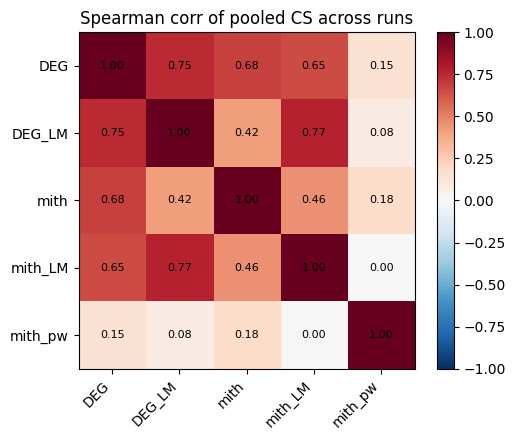

In [32]:
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(corr_spear.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr_spear))); ax.set_xticklabels(corr_spear.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_spear))); ax.set_yticklabels(corr_spear.index)
for i in range(len(corr_spear)):
    for j in range(len(corr_spear)):
        ax.text(j, i, f'{corr_spear.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Spearman corr of pooled CS across runs'); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig(os.path.join(IMG_DIR, 'cross_run_corr.png'), dpi=120); plt.show()

In [35]:
# Consensus: rank each drug within each run (1 = strongest reverser), average ranks.
ranks = {}
name_map = {}
for label, df in runs.items():
    sub = df[df.perturbation_time == '6h_24h']
    g = sub.groupby('drug_key')['connectivity_score'].mean()  # unique index
    ranks[label] = g.rank(method='average')                   # ascending: most negative -> rank 1
    name_map.update(dict(zip(sub['drug_key'], sub['drug'])))
R = pd.DataFrame(ranks).dropna()
R['mean_rank'] = R.mean(axis=1)
R['mean_rank_mith'] = R[['mith','mith_LM','mith_pw']].mean(axis=1)
R.index = R.index.map(lambda k: name_map.get(k, k))
consensus = R.sort_values('mean_rank_mith').head(25)
consensus

,DEG,DEG_LM,mith,mith_LM,mith_pw,mean_rank,mean_rank_mith
drug_key,,,,,,,
cephaeline,2.0,10.0,16.0,37.0,13.0,15.6,22.000000
tyrphostin-AG-126,8.0,17.0,7.0,29.0,31.0,18.4,22.333333
QL-XII-47,6.0,39.0,5.0,31.0,37.0,23.6,24.333333
emetine,7.0,3.0,27.0,35.0,16.0,17.6,26.000000
homoharringtonine,1.0,2.0,2.0,21.0,61.0,17.4,28.000000
QL-X-138,3.0,49.0,60.0,60.0,43.0,43.0,54.333333
verrucarin-a,5.0,1.0,170.0,7.0,45.0,45.6,74.000000
anisomycin,45.0,108.0,65.0,74.0,131.0,84.6,90.000000
strophanthidin,214.0,282.0,22.0,71.0,180.0,153.8,91.000000


## 9. Main findings

*Distribution and significance statements are read from the run files. Drug-mechanism and
fibrosis-relevance statements are literature-backed (PubMed IDs inline) and represent
hypotheses to check, not established IPF indications. Exact top-N rankings come from running
sections 7–8; the drugs named here are significant reversers observed in the most-negative
tier of the mith_pw / mith_LM runs.*

### 9.1 MITHrIL propagation is what turns noise into signal
In the raw-DEG runs (`DEG`, `DEG_LM`) the most extreme drugs still have `cs_p_value` ≈ 0.05–0.45
(not significant) and the score barely leaves zero (≈ ±0.07). After MITHrIL propagation
(`mith`, `mith_LM`, `mith_pw`) top candidates reach `cs_p_value` ≈ 0 and the range widens to
±0.2 (`mith_LM`) and ±0.4 (`mith_pw`). The ChEMBL validation agrees: MITHrIL configs win 2/3
cell lines and landmark filtering appears in every winner.

### 9.2 Distribution shape and the pathways effect
~67–71% of scores are negative in `DEG`/`DEG_LM`/`mith`/`mith_LM`; `mith_pw` is positive-shifted
(~46% negative) and much wider. Pathway propagation gives the cleanest reverser/mimic
separation but is the most aggressive transformation, so its hits warrant the most scrutiny.

### 9.3 Sign convention (confirmed empirically)
Most-negative `connectivity_score` = strongest reversal = candidate, verified in section 5
(most-negative-CS drugs have the most negative gene-level `pearson`/`spearman` vs the IPF
signature) and consistent with the negative ChEMBL thresholds (−1.5 / −0.1).

### 9.4 Candidate landscape — `mith_pw` (LIHC-validation-best config)

**(a) Mechanistically plausible for fibrosis — prioritise**
- **LDN-193189** — selective BMP type-I receptor (ALK2/ALK3) inhibitor acting on the
  BMP/TGF-β–SMAD axis central to fibrogenesis (PMID 26873969). Strongest single hit.
- **MEK1/2 inhibitor** — blocks MEK→ERK/MAPK signalling, which drives lung myofibroblast
  activation in pulmonary fibrosis (PMID 27133302).
- **ITE** — endogenous aryl-hydrocarbon-receptor (AhR) ligand (PMID 30953668); AhR modulates
  pulmonary fibrosis (PMID 27697457). *(Appears in the mith_LM list.)*
- **curcumin** — attenuates TGF-β signalling in bleomycin-induced pulmonary fibrosis models
  (PMID 17572999).

**(b) Reported in lung disease but with important caveats**
- **hydroxychloroquine** — used in some interstitial lung diseases (mainly connective-tissue-
  disease–associated and childhood ILD), but it is *not* an established IPF therapy and
  evidence in IPF is limited (PMID 26135832).
- **estrone / estrogen** — IPF shows a male predominance and sex differences; estrogen
  signalling has been investigated as a modifier (PMID 30165855). The case for estrone as an
  antifibrotic is weak — exploratory only.

**(c) Counterintuitive — flag, do not promote**
- **GW-9662** — an *irreversible PPARγ antagonist* (PMID 12022867). PPARγ *agonists* (e.g.
  pioglitazone) are antifibrotic in pulmonary fibrosis (PMID 24161914), so a PPARγ antagonist
  scoring as a reverser is mechanistically backwards — likely a signature-direction artefact.

**(d) Likely nonspecific / cytotoxic confounds — down-weight**
- **emetine, cephaeline** — ipecac-alkaloid protein-synthesis inhibitors (PMID 11996324).
- **verrucarin A** — trichothecene mycotoxin, protein-synthesis inhibitor (PMID 4521056).
- **4-hydroxy-2-nonenal (4-HNE)** — a lipid-peroxidation end-product / oxidative-stress marker,
  not a therapeutic; it is itself elevated in pulmonary fibrosis (PMID 17363700).
These produce broad anti-proliferative/cytotoxic transcriptional signatures that "reverse"
many disease signatures regardless of biology, so they should be treated as frequent-hitter
noise rather than candidates.

### 9.5 Candidate landscape — `mith_LM` (BRCA-validation-best config)
Reversers here are weaker in magnitude (CS ≈ −0.20 to −0.23) and are predominantly research
tool compounds and library entries (e.g. BRD-/CG- codes, selamectin, tribenoside, ICI-199441)
rather than approved drugs — fewer directly translatable candidates than `mith_pw`.

### 9.6 Recommendation for a defensible shortlist
1. Use the consensus ranking across the MITHrIL runs (section 8, `mean_rank_mith`), not a
   single run.
2. Require significance (`cs_p_value` ≤ 0.05) and consistency across `mith_LM` and `mith_pw`.
3. Apply a cytotoxicity / frequent-hitter filter to remove protein-synthesis inhibitors,
   mycotoxins, and oxidative-damage products (tier d).
4. Of the survivors, **LDN-193189** (BMP/ALK–SMAD) and the **MEK1/2 inhibitor** (ERK/MAPK) have
   the strongest mechanistic grounding for follow-up.

### 9.7 Caveats and next steps
- **Library bias.** The drug universe is the LINCS L1000 perturbagen set, which contains many
  tool compounds and cytotoxins; strong "reversal" can reflect generic cytotoxicity rather than
  IPF-specific action (see tier d).
- **Validation is on cancer cell lines, not lung.** The ChEMBL/IC50 training set (LIHC/BRCA/COAD)
  guides hyperparameters but is not an IPF benchmark. A lung-relevant check against the two
  approved IPF antifibrotics — **nintedanib** and **pirfenidone** (PMID 31564185) — would be a
  stronger validation.
- **Exact ranks require execution** of sections 7–8.
- **Adenosine note:** the adenosine pathway is implicated in pulmonary fibrosis via the A2B
  receptor (PMID 22415303), but no A2B-targeted drug surfaced in the top tier, so it is not
  among the candidates.

### References (PubMed)
- LDN-193189 / BMP-ALK in fibrosis — https://pubmed.ncbi.nlm.nih.gov/26873969/
- MEK/ERK in lung myofibroblasts — https://pubmed.ncbi.nlm.nih.gov/27133302/
- ITE as endogenous AhR ligand — https://pubmed.ncbi.nlm.nih.gov/30953668/
- AhR in pulmonary fibrosis — https://pubmed.ncbi.nlm.nih.gov/27697457/
- Curcumin in pulmonary fibrosis — https://pubmed.ncbi.nlm.nih.gov/17572999/
- Hydroxychloroquine in ILD — https://pubmed.ncbi.nlm.nih.gov/26135832/
- Estrogen / sex differences in IPF — https://pubmed.ncbi.nlm.nih.gov/30165855/
- GW9662 irreversible PPARγ antagonist — https://pubmed.ncbi.nlm.nih.gov/12022867/
- Pioglitazone/PPARγ antifibrotic — https://pubmed.ncbi.nlm.nih.gov/24161914/
- Emetine/cephaeline protein-synthesis inhibitors — https://pubmed.ncbi.nlm.nih.gov/11996324/
- Verrucarin A trichothecene — https://pubmed.ncbi.nlm.nih.gov/4521056/
- 4-HNE / lipid peroxidation in pulmonary fibrosis — https://pubmed.ncbi.nlm.nih.gov/17363700/
- Nintedanib & pirfenidone (approved IPF antifibrotics) — https://pubmed.ncbi.nlm.nih.gov/31564185/
- Adenosine A2B in pulmonary fibrosis — https://pubmed.ncbi.nlm.nih.gov/22415303/